In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx

In [20]:
# Function to generate association rules graph

def plot_association_graph(rules, min_confidence, min_lift, max_rules=20):
    # Filter rules based on confidence & lift
    filtered_rules = rules[(rules["confidence"] >= min_confidence) & (rules["lift"] >= min_lift)]
    
    # ✅ Check if there are any rules left
    if filtered_rules.empty:
        print(f"No strong rules meet min_confidence={min_confidence} and min_lift={min_lift}. Try lowering thresholds.")
        return
    
    # ✅ Limit number of rules to max_rules
    filtered_rules = filtered_rules.sort_values(by=["confidence", "lift"], ascending=False).head(max_rules)
    
    # Create a directed graph
    G = nx.DiGraph()
    
    for _, row in filtered_rules.iterrows():
        antecedents = ", ".join(list(row["antecedents"]))
        consequents = ", ".join(list(row["consequents"]))
        G.add_edge(antecedents, consequents, weight=row["lift"])

    # Define graph layout (force-directed for better spacing)
    plt.figure(figsize=(12, 6))
    pos = nx.spring_layout(G, seed=42, k=0.8)  # k increases spacing

    # Node sizes based on support
    node_sizes = [G.degree(n) * 800 for n in G.nodes()]  

    # Edge widths based on lift
    edges = G.edges(data=True)
    edge_widths = [d['weight'] * 3 for _, _, d in edges]

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=node_sizes, alpha=0.8)

    # Draw edges with larger arrowheads
    nx.draw_networkx_edges(
        G, pos, edgelist=edges,
        width=edge_widths,
        alpha=0.6,
        edge_color='gray',
        arrows=True,
        arrowsize=25,
        connectionstyle="arc3,rad=0.1",  # optional: gives a little curve
        min_target_margin=55  # 👈 adds spacing before the node
    )

    # Draw labels with rotation
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', verticalalignment='top')

    # Draw edge labels (Lift values)
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

    plt.title(f"Top {max_rules} Frequent Product Associations")
    plt.show()

<h1 style="color:black;text-align:center;font-size:300%;font-family:verdana;">
Rule Mining
</h1>

# 🍿 Discovering Movie Patterns with Apriori

In this notebook, we use **association rule mining** to discover interesting relationships in movies.  
Our goal is to uncover frequent combinations of movie attributes — such as genres, languages and other key factors — that often appear together.

This serves as a **pre-step** toward building a more intelligent and personalized **movie recommendation system**.

---

### 🔍 Why Apriori?

The **Apriori algorithm** is a classic and interpretable method for discovering patterns in transactional datasets.  
In our case, each *movie* is treated like a *transaction* containing various attributes (e.g., "Action", "English", "Belongs To Collection").

It helps us answer questions like:
- *Which genres often appear together?*
- *If a movie is sci-fi, how likely is it to also be part of a collection?*

## 🧭 Step 1: Define What We Want to Discover

Before diving into the Apriori algorithm, it's important to define the **questions or themes** we want to explore.  
Association rule mining is most useful when we’re curious about patterns such as:

- 🎥 *Which genres frequently appear together?*
- 🧑‍🤝‍🧑 *Do movies that release in a certain season generate more revenue?*
- 🌍 *Is there a connection between a movie’s language and its popularity level?*
- 💸 *Do high-budget movies tend to belong to collections or have taglines?*

These questions help us determine which features are relevant and how we need to preprocess them.

---

## 🔍 Step 2: Identify Features Already in Binary Format

Because **Apriori requires boolean (0/1) features**, we begin by identifying features that are already in a usable format.

Our dataset already includes several binary columns such as:
- `belongs_to_collection`
- `has_tagline`
- `has_homepage`
- `changed_title`
- `top10_prod_comps`
- `is_english_spoken`
- Genre indicators (e.g., `Action`, `Drama`, `Comedy`, etc.)

These are **ready to be fed directly into Apriori**.

---

## 🔧 Step 3: Transform Other Features (If Needed)

Based on the questions we defined, we may want to include additional features that aren’t already binary.  
For those, we need to preprocess them in one of two ways:

### Categorical Features → One-Hot Encoding
Examples:
- `main_production_country`
- `season`

We can convert the most common categories into separate binary columns (e.g., `country_USA`, `season_Summer`).

### Numeric Features → Binning → One-Hot Encoding
Examples:
- `runtime`, `budget`, `revenue`, `vote_average`, `profit_or_loss`

We'll first divide these into meaningful ranges (like short/medium/long or low/medium/high), then convert those into binary columns.

This transformation ensures we’re representing **interpretable conditions** (e.g., “High Budget” or “Popular Movie”) in a format Apriori understands.

---

By tailoring our feature selection and transformation to our questions, we ensure the resulting association rules are both valid and valuable.


In [21]:
df = pd.read_csv('tmdb_movies_cleaned.csv')

### 🎯 Choosing the Right Questions for Recommendation

Since our goal is to build a **recommendation system**, we focus on exploring rules that reflect **user preferences and content relationships** — not internal production or marketing metrics.

That means we'll prioritize **consumer-relevant patterns** and avoid less actionable insights tied to budget, revenue, or studio logistics.

Here are the key questions we’ll explore:

1. 🎭 **Genre Combinations**  
   Which genres frequently appear together, and how can this guide multi-genre recommendations?

2. 📦 **Belongs to Collection → Weighted Rating**  
   Do movies that are part of a franchise or collection tend to be rated higher?

3. ⏱️ **Movie Length → Decade Targeting**  
   Are certain movie lengths more common in specific eras?

4. 🌍 **Language → Popularity**  
   Does being English-speaking increase a movie's likelihood of being popular?

These focused explorations will help us generate **actionable rules** that enhance the intelligence and relevance of our future recommender.
___


## 🎭 Question 1: Genre Combinations

Which genres tend to appear together in movies?

Since each genre (e.g., `Action`, `Drama`, `Comedy`) is already in binary format, we can directly apply **Apriori** to uncover frequent genre pairs or groups.

We'll extract:
- Common genre itemsets
- Rules like: *If a movie is Sci-Fi, how often is it also Thriller?*

This helps us understand genre trends and can support genre-based recommendations later.


In [22]:
df.columns

Index(['id', 'title', 'runtime', 'release_date', 'budget', 'revenue',
       'popularity', 'vote_average', 'vote_count', 'belongs_to_collection',
       'has_tagline', 'has_homepage', 'num_same_title', 'changed_title',
       'num_genres', 'Crime', 'History', 'Fantasy', 'Documentary', 'Mystery',
       'Action', 'Family', 'Comedy', 'Music', 'Horror', 'TV Movie', 'Western',
       'Science Fiction', 'Adventure', 'Animation', 'Thriller', 'War',
       'Romance', 'Drama', 'top10_prod_comps', 'num_production_companies',
       'main_production_country', 'num_production_countries',
       'num_spoken_languages', 'is_english_spoken', 'popularity_percentile',
       'weighted_rating', 'release_year', 'season',
       'return_on_investment_ratio', 'profit_or_loss'],
      dtype='object')

In [23]:
genres_df = df[['Comedy', 'Action', 'Animation', 'Drama', 'History',
       'Family', 'War', 'Thriller', 'Crime', 'Adventure', 'Music', 'Fantasy',
       'Science Fiction', 'TV Movie', 'Western', 'Documentary', 'Romance',
       'Mystery', 'Horror']]

In [24]:
print(genres_df.shape)
print(genres_df.columns)

(9953, 19)
Index(['Comedy', 'Action', 'Animation', 'Drama', 'History', 'Family', 'War',
       'Thriller', 'Crime', 'Adventure', 'Music', 'Fantasy', 'Science Fiction',
       'TV Movie', 'Western', 'Documentary', 'Romance', 'Mystery', 'Horror'],
      dtype='object')


### 📊 **Apriori – Core Concepts Explained**
To understand the rules generated by the Apriori algorithm, we rely on three core metrics:

#### 🔹 1. **Support**  - How often a specific combination (A and B) appears in the dataset. 
> $$
> \text{Support}(A \Rightarrow B) = P(A \cap B)
> $$
Example: If 20% of movies are tagged as both *Action* and *Adventure*, then:  `Support = 0.20`

#### 🔹 2. **Confidence**  - Out of all the movies where A appears, how often does B also appear?
> $$
> \text{Confidence}(A \Rightarrow B) = P(B | A) = \frac{P(A \cap B)}{P(A)}
> $$

Example: If 70% of the movies with a homepage also have the *Sci-Fi* genre:`Confidence = 0.70`

#### 🔹 3. **Lift** - How much more likely A and B appear together compared to if they were independent. 
> $$
> \text{Lift}(A \Rightarrow B) = \frac{\text{Confidence}(A \Rightarrow B)}{P(B)}
> $$

  > *Lift = 1 means no association - A and B are likely independent*  
  > *Lift > 1 implies a meaningful connection - A increases the likelihood of B*  
  > *Lift < 1 implies a negative connection - A reduces the likelihood of B*  


### **Parameters**:
- `min_support`: Minimum frequency for itemsets to be considered.
- `min_confidence`: Minimum reliability for rules to be accepted.


In [25]:
frequent_itemsets1 = apriori(genres_df, min_support=0.1, use_colnames=True)

print("Frequent Movie Genres Discovered:")
print(frequent_itemsets1.sort_values(by='support', ascending=False))

Frequent Movie Genres Discovered:
     support           itemsets
2   0.485482            (Drama)
0   0.369939           (Comedy)
4   0.240430         (Thriller)
1   0.231890           (Action)
7   0.203155          (Romance)
6   0.169095        (Adventure)
5   0.157641            (Crime)
12  0.130011   (Drama, Romance)
9   0.120868    (Comedy, Drama)
8   0.111323           (Horror)
10  0.104692  (Comedy, Romance)
11  0.102281  (Drama, Thriller)
3   0.100573           (Family)


In [26]:
rules1 = association_rules(frequent_itemsets1, metric="confidence", min_threshold=0.1)

print("Association Rules Discovered:")
print(rules1[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Association Rules Discovered:
  antecedents consequents   support  confidence      lift
0    (Comedy)     (Drama)  0.120868    0.326725  0.672990
1     (Drama)    (Comedy)  0.120868    0.248965  0.672990
2    (Comedy)   (Romance)  0.104692    0.282998  1.393018
3   (Romance)    (Comedy)  0.104692    0.515331  1.393018
4     (Drama)  (Thriller)  0.102281    0.210679  0.876258
5  (Thriller)     (Drama)  0.102281    0.425407  0.876258
6     (Drama)   (Romance)  0.130011    0.267798  1.318197
7   (Romance)     (Drama)  0.130011    0.639960  1.318197


### ✅ Example of a Strong Association Rule vs. a Weak Association Rule

Based on the key metrics (**Support**, **Confidence**, and **Lift**), we can evaluate the quality of association rules generated by the Apriori algorithm.
___

#### 💪 Good Rule Example: `Romance → Drama`

| Metric      | Value    |
|-------------|----------|
| Support     | 0.1300   |
| Confidence  | 0.6399   |
| Lift        | 1.3182   |

**Explanation**:
- 13% of all movies are tagged as both *Romance* and *Drama*.
- Among *Romance* movies, nearly **64%** are also *Drama* — a strong and reliable association.
- The **lift is 1.32**, meaning *Romance* and *Drama* co-occur **32% more often than expected by chance**.
- ✅ This is a strong, meaningful rule — great for recommendation systems.

---

#### ❌ Weak Rule Example: `Drama → Comedy`

| Metric      | Value    |
|-------------|----------|
| Support     | 0.1209   |
| Confidence  | 0.2490   |
| Lift        | 0.6730   |

**Explanation**:
- The combination appears in 12% of movies — moderately frequent.
- But only **25%** of *Drama* movies are also *Comedy* — a low reliability.
- Worse: the **lift is below 1**, which means *Drama* and *Comedy* appear **together less often than expected by chance**.
- ❌ This is a weak and potentially misleading rule — not recommended for use.


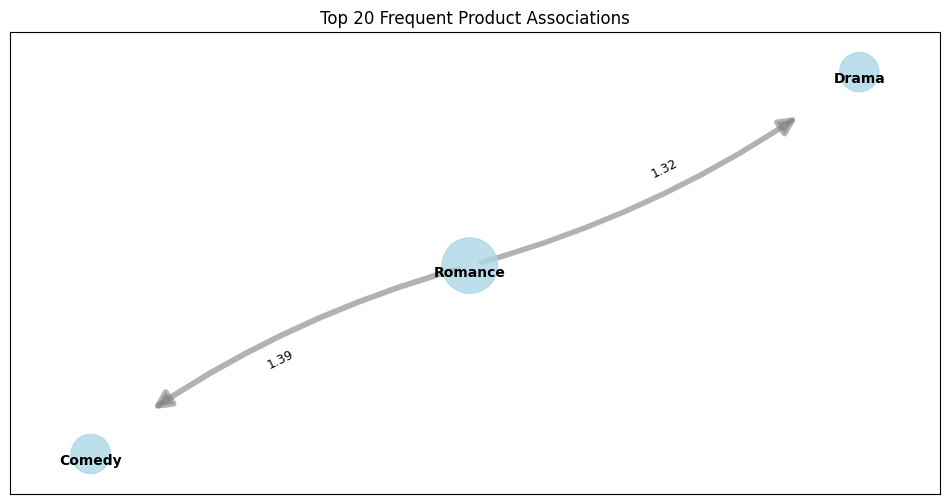

In [27]:
# We chose these thresholds (confidence ≥ 0.5, lift ≥ 1.1) to visualize only strong and meaningful associations.
plot_association_graph(rules1, min_confidence=0.5, min_lift=1.1)


### 🤔 Understanding the metrics for `Romance` -> `Drama`:
* The highest **combination** of movie genres, at about 13% of all movies, is `Romance-Drama`.  
* The likelihood of a `Romance` movie being also a `Drama` movie is around 64%.  
* `Romance` and `Drama` are more often together then independently by about 32%.  

Conclusion: If you're watching a `Romance` movie, you're significantly more likely to also be watching a `Drama`, compared to picking genres at random.  

### 📈 Deeper Implications of the `Romance` → `Drama` Rule

Beyond the basic lift and confidence values, this association rule between `Romance` and `Drama` reveals several useful insights:

- 🌀 **Genre Blending Insight**:  
  The frequent co-occurrence suggests that `Romance` and `Drama` are often intentionally blended in storytelling to create emotionally engaging narratives.

- 🎯 **Audience Preferences**:  
  Users who enjoy `Romance` are statistically more likely to also enjoy or tolerate `Drama`. This can help personalize recommendations even if a user only selects `Romance`.

- 🎭 **Labeling and Expectation Setting**:  
  With 64% of Romance movies also tagged as Drama, "pure" Romance films are relatively rare. This helps manage user expectations — most Romance films will likely include serious or emotional storylines.

- 🔁 **Asymmetry Matters**:  
  The rule is directional: while most Romance films are also Drama, not all Drama films are Romance. This asymmetry is important when building logic for recommendations or genre-based filters.

- 🤖 **Recommendation Engine Tip**:  
  You can use this rule in your content-based recommender system by increasing the weight of `Drama` for users who show a preference for `Romance`, even without them explicitly stating it.

___

In [28]:
# We filtered the association rules to keep only the strong and meaningful ones.
rules1 = rules1[
    (rules1['confidence'] >= 0.5) &
    (rules1['lift'] >= 0.8) &
    (rules1['support'] >= 0.1)
]
print("Number of remaining rules:", rules1.shape[0])

Number of remaining rules: 2


In [29]:
print(rules1[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

  antecedents consequents   support  confidence      lift
3   (Romance)    (Comedy)  0.104692    0.515331  1.393018
7   (Romance)     (Drama)  0.130011    0.639960  1.318197


### ✅ Filtering for Strong Association Rules Only

To ensure that we only generate **reliable and meaningful recommendations**,  
we filtered the rules using strict thresholds. 
As a result, only rules related to the 'Romance' genre met the criteria.  
This means that, at this stage, recommendations are only generated for users who have watched Romance movies.

We are **aware of this limitation**, and later in the code we address it by combining of Association rules and Cosine similarity.

For genres that currently have no strong associations, the system will clearly state:  
> *"No strong recommendations found for your selected genres."*


In [30]:
def recommend_genres(watched_items, rules, top_n=2):
    recommendations = []
    seen_recommendations = set()  # To track unique recommendations
    
    for _, row in rules.iterrows():
        antecedents = row['antecedents']
        consequents = row['consequents']
        support = row['support']
        confidence = row['confidence']
        lift = row['lift']
        
        # If the antecedents (watched items) match the rule, recommend the consequents
        if antecedents.issubset(watched_items):
            recommended_items = list(consequents - watched_items)  # Exclude already watched items
            for item in recommended_items:
                if item not in seen_recommendations:  # Prevent duplicate recommendations
                    seen_recommendations.add(item)
                    recommendations.append((item, support, confidence, lift))
    
    # Sort recommendations by confidence and lift (stronger rules first)
    recommendations.sort(key=lambda x: (x[2], x[3]), reverse=True)  # Sort by confidence & lift
    
    # Select the top_n recommendations
    best_recommendations = recommendations[:top_n]

    # Check if there are no recommendations at all
    if not best_recommendations:
        return ["No strong recommendations found for your selected genres."]
    
    # Format the explanation
    formatted_recommendations = []
    for rec in best_recommendations:
        item, support, confidence, lift = rec
        explanation = (
            f"If you watched {watched_items} I recommend you also watch: {item}.\n"
            f"Supported by metrics: Support: {support:.2f} | Confidence: {confidence:.2f} | Lift: {lift:.2f}."
        )
        formatted_recommendations.append(explanation)
    
    return formatted_recommendations

In [31]:
# Example Usage:
watched_genres = {"Romance"}  # Assume the customer watched these

recommendations = recommend_genres(watched_genres, rules1)

# Display Recommendations
for rec in recommendations:
    print(rec)

If you watched {'Romance'} I recommend you also watch: Drama.
Supported by metrics: Support: 0.13 | Confidence: 0.64 | Lift: 1.32.
If you watched {'Romance'} I recommend you also watch: Comedy.
Supported by metrics: Support: 0.10 | Confidence: 0.52 | Lift: 1.39.


In [32]:
# This is an example of a genre that currently has no strong recommendations:
watched_genres = {"Drama"}  # Assume the customer watched these

recommendations = recommend_genres(watched_genres, rules1)

# Display Recommendations
for rec in recommendations:
    print(rec)

No strong recommendations found for your selected genres.


In [33]:
# This function recommends actual movies based on genre association rules.

def recommend_movies_from_genre_rules(user_genres, rules, df, top_n_genres=3, top_n_movies=5, min_confidence=0.5, min_lift=1.0):
    # Apply confidence & lift filters first
    filtered_rules = rules[(rules['confidence'] >= min_confidence) & (rules['lift'] >= min_lift)]

    genre_recs = []
    seen_genres = set()

    for _, row in filtered_rules.iterrows():
        antecedents = set(row['antecedents'])
        consequents = set(row['consequents'])
        support = row['support']
        confidence = row['confidence']
        lift = row['lift']

        if antecedents.issubset(user_genres):
            new_genres = consequents - user_genres
            for genre in new_genres:
                if genre not in seen_genres:
                    seen_genres.add(genre)
                    genre_recs.append((genre, support, confidence, lift))

    best_genres = [rec[0] for rec in genre_recs[:top_n_genres]]

    if not best_genres:
        return "No new genres to recommend based on current rules and thresholds."

    # Filter movies matching at least one of recommended genres
    movie_candidates = df.copy()
    genre_condition = movie_candidates[best_genres].sum(axis=1) >= 1
    movie_candidates = movie_candidates[genre_condition]

    # Sort by weighted_rating
    if 'weighted_rating' in movie_candidates.columns:
        movie_candidates = movie_candidates.sort_values(by='weighted_rating', ascending=False)

    return movie_candidates[['title'] + best_genres + ['weighted_rating']].head(top_n_movies)


In [34]:
# Example Usage:
user_genres = {'Romance'}

# Print a heading before showing the movie recommendations
print(f"🎬 Because you enjoy {user_genres} movies, here are some top-rated suggestions:")

# The movies are sorted by weighted rating
recommend_movies_from_genre_rules(user_genres, rules1, df, top_n_genres=3, top_n_movies=25, min_confidence=0.5, min_lift=0.8)

🎬 Because you enjoy {'Romance'} movies, here are some top-rated suggestions:


,title,Comedy,Drama,weighted_rating
169,The Shawshank Redemption,False,True,8.699763
144,The Godfather,False,True,8.676245
146,The Godfather Part II,False,True,8.553137
247,Schindler's List,False,True,8.550724
227,12 Angry Men,False,True,8.524364
89,The Dark Knight,False,True,8.512667
284,The Green Mile,False,True,8.492252
9912,Parasite,True,True,8.488864
4378,Dilwale Dulhania Le Jayenge,True,True,8.469272
4,Forrest Gump,True,True,8.460581


___
## 📦 Question 2: Collections and Ratings

Do movies that belong to a collection tend to receive higher ratings?

By analyzing the binary feature `belongs_to_collection` alongside `weighted_rating` (after binning it into categories), we can use **Apriori** to discover if being part of a franchise correlates with higher audience approval.

We'll extract:
- Rules like: *If a movie belongs to a collection, how likely is it to be highly rated?*

This can help us understand whether franchise association is a quality signal in recommendations.


In [36]:
# print(f"The minimum value for weighted rating is: {df['weighted_rating'].min().round(2)} and the maximum value is: {df['weighted_rating'].max().round(2)}")

In [37]:
# Check for null values in 'weighted_rating'
df['weighted_rating'].isnull().any()

False

In [38]:
df['belongs_to_collection'] = df['belongs_to_collection'].astype(bool)

In [39]:
# Define the bins and labels
bins = [3, 4, 5, 6, 7, 8, 9]
labels = ['3-4', '4-5', '5-6', '6-7', '7-8', '8-9']

df['binned_rating'] = pd.cut(df['weighted_rating'], bins=bins, labels=labels, include_lowest=False)

In [40]:
df[['weighted_rating', 'binned_rating']]

,weighted_rating,binned_rating
0,5.915191,5-6
1,6.430314,6-7
2,8.194340,8-9
3,7.808617,7-8
4,8.460581,8-9
...,...,...
9948,5.821839,5-6
9949,6.250978,6-7
9950,6.092949,6-7
9951,6.179887,6-7


In [41]:
q2_df = df[['belongs_to_collection', 'binned_rating']].copy()

In [42]:
q2_df = pd.get_dummies(q2_df, columns=['binned_rating'])

In [43]:
q2_df

,belongs_to_collection,binned_rating_3-4,binned_rating_4-5,binned_rating_5-6,binned_rating_6-7,binned_rating_7-8,binned_rating_8-9
0,False,False,False,True,False,False,False
1,False,False,False,False,True,False,False
2,True,False,False,False,False,False,True
3,True,False,False,False,False,True,False
4,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...
9948,False,False,False,True,False,False,False
9949,True,False,False,False,True,False,False
9950,True,False,False,False,True,False,False
9951,False,False,False,False,True,False,False


In [44]:
frequent_itemsets2 = apriori(q2_df, min_support=0.1, use_colnames=True)

print("Frequent Itemsets for Binned Ratings and Collections:")
print(frequent_itemsets2.sort_values(by='support', ascending=False))

Frequent Itemsets for Binned Ratings and Collections:
    support                                    itemsets
2  0.627349                         (binned_rating_6-7)
0  0.220436                     (belongs_to_collection)
1  0.186175                         (binned_rating_5-6)
3  0.160956                         (binned_rating_7-8)
4  0.123480  (binned_rating_6-7, belongs_to_collection)


In [45]:
rules2 = association_rules(frequent_itemsets2, metric="confidence", min_threshold=0.1)

print("Association Rules Discovered:")
print(rules2[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_string(index=False))

Association Rules Discovered:
            antecedents             consequents  support  confidence     lift
    (binned_rating_6-7) (belongs_to_collection)  0.12348    0.196829 0.892907
(belongs_to_collection)     (binned_rating_6-7)  0.12348    0.560164 0.892907


❌ We chose **not** to filter out weak rules here, because strict thresholds would leave us with no rules at all.  
Even though these rules are not strong, they still show a small pattern that may be helpful.

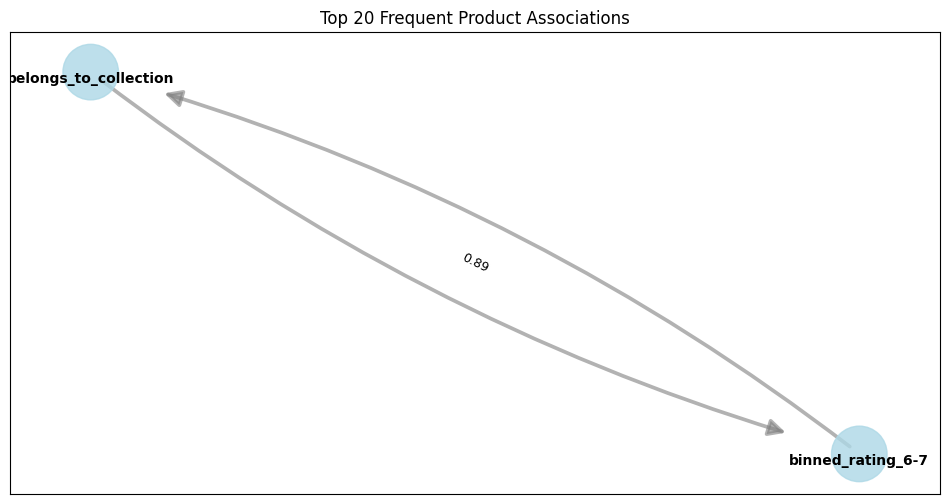

In [46]:
plot_association_graph(rules2, min_confidence=0.1, min_lift=0.8)

### 🤔 Do Collections Tend to Have Higher Ratings?
- `binned_rating_6-7` is the **most common rating group**, covering **62.7%** of all movies.
- `belongs_to_collection` applies to **22%** of movies.
- The combination of both — collection movies with a 6–7 rating — occurs in **12.3%** of the dataset.

### 🔄 Association Rule Results:
- **Rule**: `belongs_to_collection → binned_rating_6-7`
  - **Confidence**: 56%
  - **Lift**: 0.89 (i.e., 11% *less* likely than random)
  
- **Rule**: `binned_rating_6-7 → belongs_to_collection`
  - **Confidence**: 19.7%
  - **Lift**: 0.89

### 🎯 Conclusion:
Although over half of collection movies fall into the 6–7 rating group, this is mainly because that rating bin is **common overall** — not because collections are especially likely to score that way.

The **lift < 1** suggests that being in a collection does **not meaningfully increase** the chance of having a 6–7 rating.  
In fact, the pairing occurs **slightly less often than chance would predict**, implying **no strong positive association** between collections and mid-to-high ratings.

___

In [47]:
def recommend_feature_values(watched_features, rules, top_n=2):
    
    recommendations = []
    seen_recommendations = set()

    for _, row in rules.iterrows():
        antecedents = set(row['antecedents'])
        consequents = set(row['consequents'])
        support = row['support']
        confidence = row['confidence']
        lift = row['lift']

        if antecedents.issubset(watched_features):
            new_recs = consequents - watched_features
            for rec in new_recs:
                if rec not in seen_recommendations:
                    seen_recommendations.add(rec)
                    recommendations.append((rec, support, confidence, lift))

    recommendations.sort(key=lambda x: (x[2], x[3]), reverse=True)
    best_recommendations = recommendations[:top_n]

    formatted_recommendations = []
    for rec in best_recommendations:
        item, support, confidence, lift = rec
        explanation = (
            f"Since you want: {watched_features}, you may like: {item}. \n"
            f"Supported by: Support: {support:.2f}, Confidence: {confidence:.2f}, Lift: {lift:.2f}."
        )
        formatted_recommendations.append(explanation)

    return formatted_recommendations


In [48]:
# Example Usage:
watched_features = {'binned_rating_6-7'}

print(recommend_feature_values(watched_features, rules2, top_n=3))

["Since you want: {'binned_rating_6-7'}, you may like: belongs_to_collection. \nSupported by: Support: 0.12, Confidence: 0.20, Lift: 0.89."]


In [49]:
def recommend_movies_from_feature_rules(watched_features, rules, df, top_n_features=3, top_n_movies=5, min_confidence=0.5, min_lift=1.0):
    
    filtered_rules = rules[(rules['confidence'] >= min_confidence) & (rules['lift'] >= min_lift)]

    feature_recs = []
    seen_features = set()

    for _, row in filtered_rules.iterrows():
        antecedents = set(row['antecedents'])
        consequents = set(row['consequents'])
        support = row['support']
        confidence = row['confidence']
        lift = row['lift']

        if antecedents.issubset(watched_features):
            new_features = consequents - watched_features
            for feature in new_features:
                if feature not in seen_features:
                    seen_features.add(feature)
                    feature_recs.append((feature, support, confidence, lift))

    feature_recs.sort(key=lambda x: (x[2], x[3]), reverse=True)
    best_features = [rec[0] for rec in feature_recs[:top_n_features]]

    if not best_features:
        return "No new features to recommend based on current rules and thresholds."

    # Now filter movies that match at least one of these features
    movie_candidates = df.copy()

    # We must dynamically check columns based on these feature values
    feature_conditions = []
    for feature in best_features:
        if feature.startswith('binned_rating_'):
            rating_range = feature.replace('binned_rating_', '').split('-')
            lower = float(rating_range[0])
            upper = float(rating_range[1])
            feature_conditions.append((df['vote_average'] >= lower) & (df['vote_average'] < upper))
        elif feature == 'belongs_to_collection':
            feature_conditions.append(df['belongs_to_collection'].notnull())
        else:
            # fallback for unknown feature
            continue

    if feature_conditions:
        combined_condition = feature_conditions[0]
        for cond in feature_conditions[1:]:
            combined_condition |= cond

        movie_candidates = movie_candidates[combined_condition]
    else:
        return "No matching movies found for recommended features."

    # Sort by weighted_rating if available
    if 'weighted_rating' in movie_candidates.columns:
        movie_candidates = movie_candidates.sort_values(by='weighted_rating', ascending=False)

    # Show the relevant features + title
    columns_to_return = ['title']
    if 'weighted_rating' in movie_candidates.columns:
        columns_to_return.append('weighted_rating')

    return movie_candidates[columns_to_return].head(top_n_movies)


In [50]:
# Example Usage:
watched_features = {'belongs_to_collection'}

recommend_movies_from_feature_rules(watched_features, rules2, df, top_n_features=3, top_n_movies=5, min_confidence=0.2, min_lift=0.8)

,title,weighted_rating
5616,Megamind,6.989771
553,Cars,6.989482
577,Mission: Impossible,6.988948
8498,Shazam!,6.987367
8812,10 Cloverfield Lane,6.985094


___
## ⏱️ Question 3: Movie Length and Decade Preference

Are certain movie lengths more typical of specific decades — and can that help guide time-based recommendations?

We'll categorize `runtime` into bins like `Short`, `Medium`, and `Long`, and explore associations with the `release_year` (grouped into decades).

We'll extract:
- Rules like: *If a user wants a short movie, suggest titles from the 2010s.*

This helps match user time constraints with appropriate eras in film history.


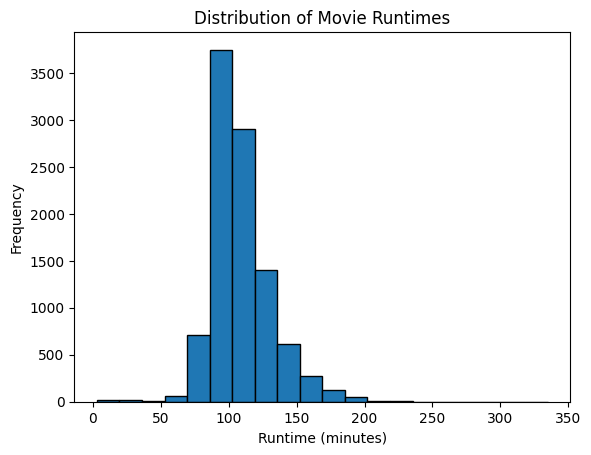

In [51]:
plt.hist(df['runtime'], bins=20, edgecolor='black')
plt.title("Distribution of Movie Runtimes")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Frequency")
plt.show()

In [52]:
# Define the bins and labels
bins = [0, 60, 90, 120, np.inf]
labels = ['Short(Under 60 Mins)', 'Medium(60-90 Mins)', 'Long(90-120 Mins)', 'Very Long(Over 120 Mins)']

df['binned_runtime'] = pd.cut(df['runtime'], bins=bins, labels=labels, include_lowest=False)

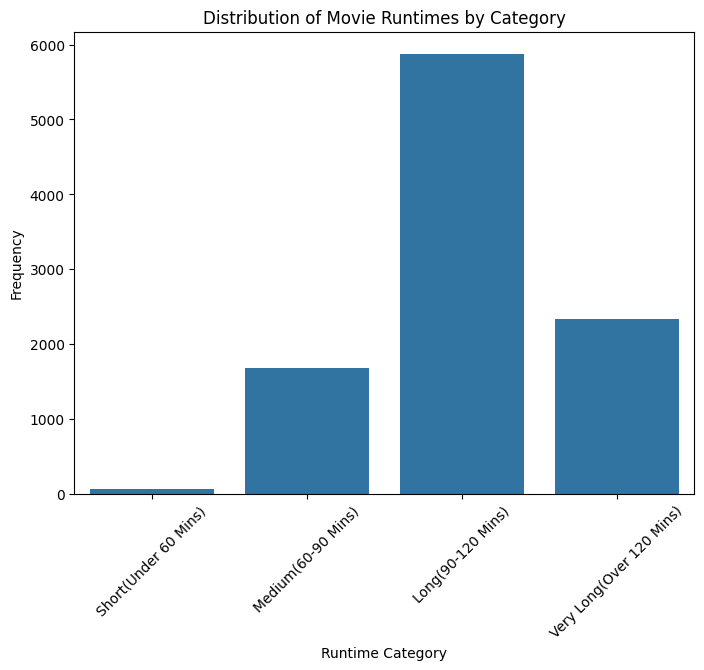

In [53]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='binned_runtime')
plt.title("Distribution of Movie Runtimes by Category")
plt.xticks(rotation=45)
plt.xlabel("Runtime Category")
plt.ylabel("Frequency")
plt.show()

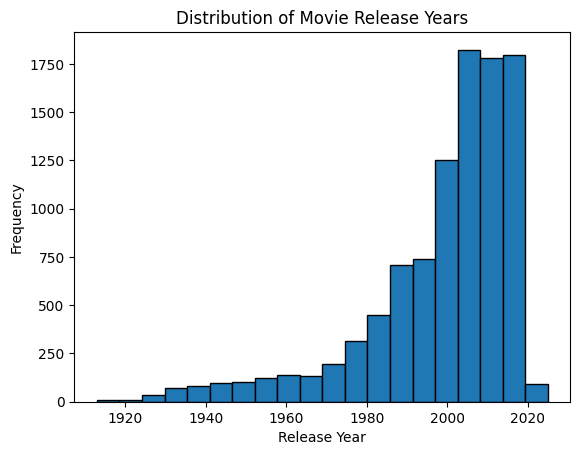

In [54]:
plt.hist(df['release_year'], bins=20, edgecolor='black')
plt.title("Distribution of Movie Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

In [55]:
print(f"The minimum release year is: {df['release_year'].min()} and the maximum is: {df['release_year'].max()}")

The minimum release year is: 1913 and the maximum is: 2025


In [56]:
# Define the bins and labels
bins = [0, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020, np.inf]
labels = ['1910s', '1920s', '1930s', '1940s', '1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

df['binned_release_year'] = pd.cut(df['release_year'], bins=bins, labels=labels, include_lowest=False)

In [57]:
df['binned_release_year']

0       1990s
1       1990s
2       1970s
3       2000s
4       1990s
        ...  
9948    2010s
9949    2010s
9950    2010s
9951    2010s
9952    2010s
Name: binned_release_year, Length: 9953, dtype: category
Categories (12, object): ['1910s' < '1920s' < '1930s' < '1940s' ... '1990s' < '2000s' < '2010s' < '2020s']

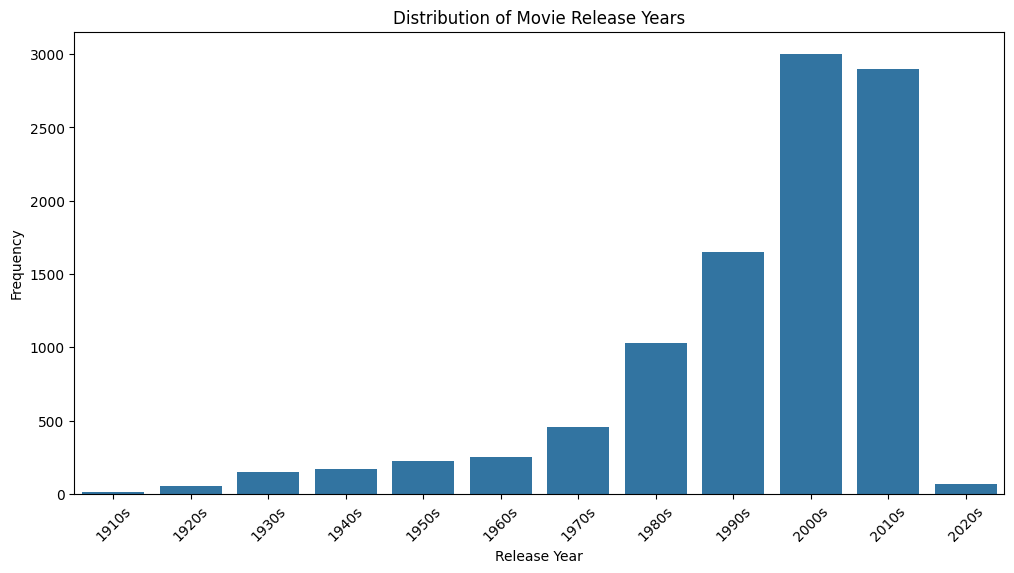

In [58]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='binned_release_year')
plt.title("Distribution of Movie Release Years")
plt.xticks(rotation=45)
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

In [59]:
q3_df = df[['binned_runtime', 'binned_release_year']].copy()

In [60]:
q3_df = pd.get_dummies(q3_df)

In [61]:
q3_df

,binned_runtime_Short(Under 60 Mins),binned_runtime_Medium(60-90 Mins),binned_runtime_Long(90-120 Mins),binned_runtime_Very Long(Over 120 Mins),binned_release_year_1910s,binned_release_year_1920s,binned_release_year_1930s,binned_release_year_1940s,binned_release_year_1950s,binned_release_year_1960s,binned_release_year_1970s,binned_release_year_1980s,binned_release_year_1990s,binned_release_year_2000s,binned_release_year_2010s,binned_release_year_2020s
0,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9948,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
9949,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
9950,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
9951,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False


In [62]:
frequent_itemsets3 = apriori(q3_df, min_support=0.1, use_colnames=True)

print("Frequent Itemsets for Binned Runtimes and Release Years:")
print(frequent_itemsets3.sort_values(by='support', ascending=False))

Frequent Itemsets for Binned Runtimes and Release Years:
    support                                           itemsets
1  0.590777                 (binned_runtime_Long(90-120 Mins))
5  0.301718                        (binned_release_year_2000s)
6  0.291269                        (binned_release_year_2010s)
2  0.234904          (binned_runtime_Very Long(Over 120 Mins))
8  0.179343  (binned_runtime_Long(90-120 Mins), binned_rele...
0  0.168693                (binned_runtime_Medium(60-90 Mins))
9  0.167889  (binned_runtime_Long(90-120 Mins), binned_rele...
4  0.165679                        (binned_release_year_1990s)
3  0.103185                        (binned_release_year_1980s)
7  0.101376  (binned_runtime_Long(90-120 Mins), binned_rele...


In [63]:
rules3 = association_rules(frequent_itemsets3, metric="confidence", min_threshold=0.2)

print("Association Rules Discovered:")
rules3[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

Association Rules Discovered:


,antecedents,consequents,support,confidence,lift
0,(binned_release_year_1990s),(binned_runtime_Long(90-120 Mins)),0.101376,0.611886,1.035732
1,(binned_runtime_Long(90-120 Mins)),(binned_release_year_2000s),0.179343,0.303571,1.006143
2,(binned_release_year_2000s),(binned_runtime_Long(90-120 Mins)),0.179343,0.594406,1.006143
3,(binned_runtime_Long(90-120 Mins)),(binned_release_year_2010s),0.167889,0.284184,0.975674
4,(binned_release_year_2010s),(binned_runtime_Long(90-120 Mins)),0.167889,0.576406,0.975674


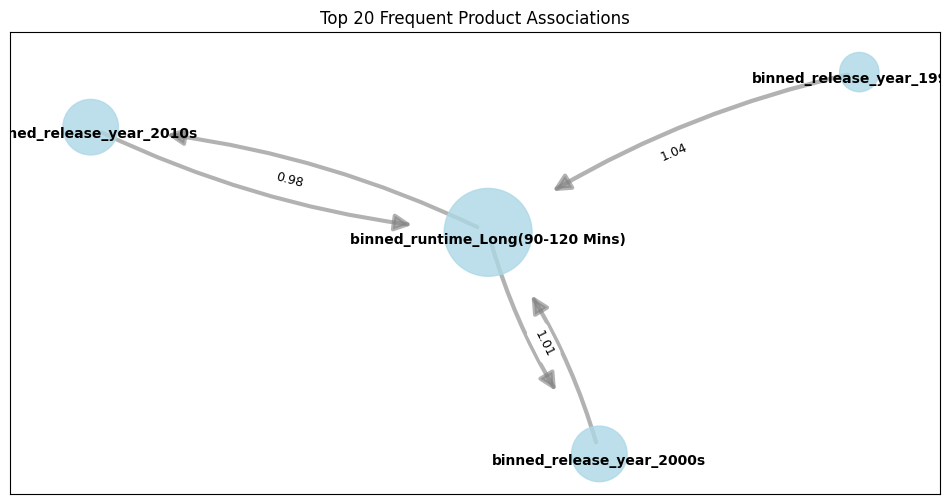

In [64]:
plot_association_graph(rules3, min_confidence=0.2, min_lift=0.95)

### 🤔 Runtime and Decade Preferences

Here's what we found:

### 1️⃣ 1990s Movies Tend to Be 90–120 Minutes Long  
- **Rule**: `1990s → 90–120 mins`  
- **Confidence**: 61.2%  
- **Lift**: 1.036  
📌 **Conclusion**: If you're looking for a movie from the 1990s, you're slightly more likely to find it in the common 90–120 minute range. While not a strong association, it's above random.


### 2️⃣ 2000s and Runtime: Mutual Weak Association  
- **Rule**: `90–120 mins → 2000s` → Confidence: 30%, Lift: ~1.006  
- **Rule**: `2000s → 90–120 mins` → Confidence: 59%, Lift: ~1.006  
📌 **Conclusion**: There's a **mild two-way association** between 2000s films and standard-length movies. The relationship exists in both directions, but the lift near 1.0 means it's **neutral and not particularly insightful** for recommendations.


### 3️⃣ 2010s and Runtime: Slight Negative Correlation  
- **Rule**: `90–120 mins → 2010s` → Confidence: 28%, Lift: ~0.976  
- **Rule**: `2010s → 90–120 mins` → Confidence: 58%, Lift: ~0.976  
📌 **Conclusion**: Although over half of 2010s movies are in the 90–120 min range, that’s mostly due to this runtime being common in general.  
   The **lift below 1.0** suggests that 2010s movies are **slightly less likely** to fall in this range than you'd expect by chance.



### 🎯 Conclusion:
While runtime distributions vary slightly by decade, the lift values (~1.0) indicate there's **no strong decade-based bias** for runtime categories.  
Still, minor trends can be useful: if a user wants a **90–120 min film**, looking into the 1990s or 2000s could slightly increase the odds.
____


In [65]:
def recommend_features(watched_features, rules, top_n=2):

    recommendations = []
    seen_recommendations = set()

    for _, row in rules.iterrows():
        antecedents = set(row['antecedents'])
        consequents = set(row['consequents'])
        support = row['support']
        confidence = row['confidence']
        lift = row['lift']

        if antecedents.issubset(watched_features):
            new_recs = consequents - watched_features
            for rec in new_recs:
                if rec not in seen_recommendations:
                    seen_recommendations.add(rec)
                    recommendations.append((rec, support, confidence, lift))

    recommendations.sort(key=lambda x: (x[2], x[3]), reverse=True)
    best_recommendations = recommendations[:top_n]

    formatted_recommendations = []
    for rec in best_recommendations:
        item, support, confidence, lift = rec
        explanation = (
            f"If you want: {watched_features}, I recommend: {item}.\n"
            f"Support: {support:.2f}, Confidence: {confidence:.2f}, Lift: {lift:.2f}."
        )
        formatted_recommendations.append(explanation)

    return formatted_recommendations


In [66]:
# Rule-based feature recommendation:
watched_features = {"binned_release_year_2000s"}
recommendations = recommend_features(watched_features, rules3)

for rec in recommendations:
    print(rec)

If you want: {'binned_release_year_2000s'}, I recommend: binned_runtime_Long(90-120 Mins).
Support: 0.18, Confidence: 0.59, Lift: 1.01.


In [67]:
def recommend_movies_from_feature_rules(watched_features, rules, df, top_n_features=3, top_n_movies=5, min_confidence=0.5, min_lift=1.0):

    filtered_rules = rules[(rules['confidence'] >= min_confidence) & (rules['lift'] >= min_lift)]

    feature_recs = []
    seen_features = set()

    for _, row in filtered_rules.iterrows():
        antecedents = set(row['antecedents'])
        consequents = set(row['consequents'])
        support = row['support']
        confidence = row['confidence']
        lift = row['lift']

        if antecedents.issubset(watched_features):
            new_features = consequents - watched_features
            for feature in new_features:
                if feature not in seen_features:
                    seen_features.add(feature)
                    feature_recs.append((feature, support, confidence, lift))

    feature_recs.sort(key=lambda x: (x[2], x[3]), reverse=True)
    best_features = [rec[0] for rec in feature_recs[:top_n_features]]

    if not best_features:
        return "No new features to recommend based on current rules and thresholds."

    # Now filter movies that match any of these features
    movie_candidates = df.copy()

    feature_conditions = []
    for feature in best_features:
        if feature.startswith('binned_release_year_'):
            decade = feature.replace('binned_release_year_', '')
            condition = df['binned_release_year'] == decade
            feature_conditions.append(condition)
        elif feature.startswith('binned_runtime_'):
            runtime_label = feature.replace('binned_runtime_', '')
            condition = df['binned_runtime'] == runtime_label
            feature_conditions.append(condition)
        else:
            continue  # unknown feature type

    if not feature_conditions:
        return "No matching movies found for recommended features."

    combined_condition = feature_conditions[0]
    for condition in feature_conditions[1:]:
        combined_condition |= condition

    movie_candidates = movie_candidates[combined_condition]

    if 'weighted_rating' in movie_candidates.columns:
        movie_candidates = movie_candidates.sort_values(by='weighted_rating', ascending=False)

    columns_to_return = ['title']
    if 'weighted_rating' in movie_candidates.columns:
        columns_to_return.append('weighted_rating')

    return movie_candidates[columns_to_return].head(top_n_movies)


In [68]:
# Example Usage:
watched_features = {"binned_release_year_2000s"}

movie_recommendations = recommend_movies_from_feature_rules(watched_features, rules3, df, top_n_features=3, top_n_movies=5, min_confidence=0.5, min_lift=0.95)
print(movie_recommendations)

                                  title  weighted_rating
227                        12 Angry Men         8.524364
380                   Life Is Beautiful         8.433535
305                              Psycho         8.403326
8753  Spider-Man: Into the Spider-Verse         8.384490
1314               Howl's Moving Castle         8.376443


___
## 🌍 Question 4: Language and Popularity

Does speaking English correlate with a higher chance of popularity?

Using the binary feature `is_english_spoken` and a binned version of `popularity`, we’ll explore how language impacts a movie’s reach.

We'll extract:
- Rules like: *If a movie is in English, how likely is it to fall into the top popularity tier?*

These insights can support language-aware recommendations, especially for international or multilingual users.


In [69]:
df['popularity'].describe()

count    9953.000000
mean        4.518899
std         7.265972
min         0.012500
25%         1.533100
50%         2.958000
75%         5.312600
max       390.447100
Name: popularity, dtype: float64

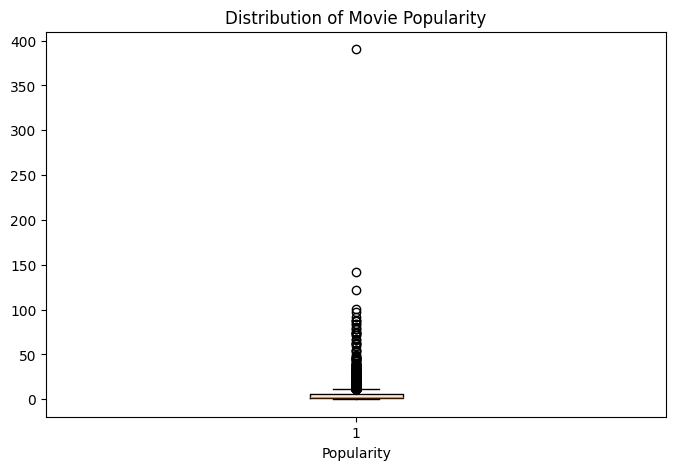

In [70]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['popularity'])
plt.title("Distribution of Movie Popularity")
plt.xlabel("Popularity")
plt.show()

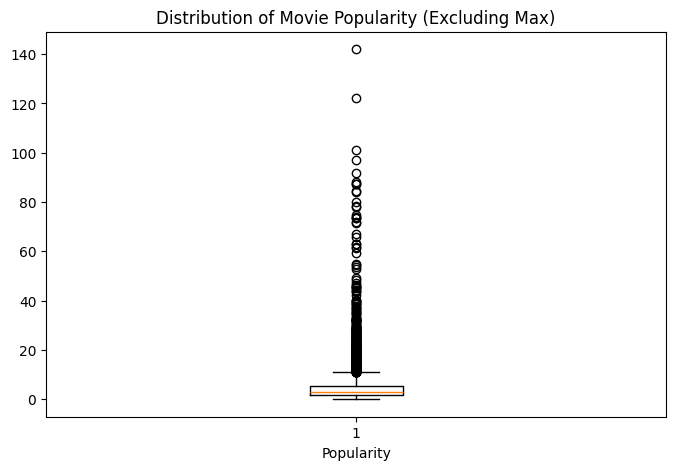

In [71]:
popularity_trimmed = df['popularity'][df['popularity'] < df['popularity'].max()]

plt.figure(figsize=(8, 5))
plt.boxplot(popularity_trimmed)
plt.title("Distribution of Movie Popularity (Excluding Max)")
plt.xlabel("Popularity")
plt.show()

### 📉 Why Raw Popularity Isn’t Reliable

The `popularity` feature is extremely skewed — it's heavily influenced by recency and current trends.  
Since most of the movies in our dataset are **not recent**, their popularity scores are disproportionately low, making this metric an unreliable indicator of true audience interest.

While using **popularity percentiles** offers a slightly better perspective, the reality remains:  
> More than 75% of the movies have very low popularity scores.

📌 **Conclusion**:  
To ensure fair and meaningful insights, we should consider testing **alternative features** that better reflect long-term audience value or engagement.  
We will change the feature to `weighted_rating` binned from our previous question.

In [72]:
q4_df = df[['is_english_spoken', 'binned_rating']].copy()

In [73]:
q4_df = pd.get_dummies(q4_df, columns=['binned_rating'])

In [74]:
frequent_itemsets4 = apriori(q4_df, min_support=0.1, use_colnames=True)

print("Frequent Itemsets for English Spoken Movies and Binned Ratings:")
print(frequent_itemsets4.sort_values(by='support', ascending=False))

Frequent Itemsets for English Spoken Movies and Binned Ratings:
    support                                itemsets
0  0.825379                     (is_english_spoken)
2  0.627349                     (binned_rating_6-7)
5  0.494122  (is_english_spoken, binned_rating_6-7)
1  0.186175                     (binned_rating_5-6)
4  0.169095  (is_english_spoken, binned_rating_5-6)
3  0.160956                     (binned_rating_7-8)
6  0.139556  (binned_rating_7-8, is_english_spoken)


In [75]:
rules4 = association_rules(frequent_itemsets4, metric="confidence", min_threshold=0.2)

print("Association Rules Discovered:")
print(rules4[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Association Rules Discovered:
           antecedents          consequents   support  confidence      lift
0  (is_english_spoken)  (binned_rating_5-6)  0.169095    0.204869  1.100412
1  (binned_rating_5-6)  (is_english_spoken)  0.169095    0.908257  1.100412
2  (is_english_spoken)  (binned_rating_6-7)  0.494122    0.598661  0.954272
3  (binned_rating_6-7)  (is_english_spoken)  0.494122    0.787636  0.954272
4  (binned_rating_7-8)  (is_english_spoken)  0.139556    0.867041  1.050476


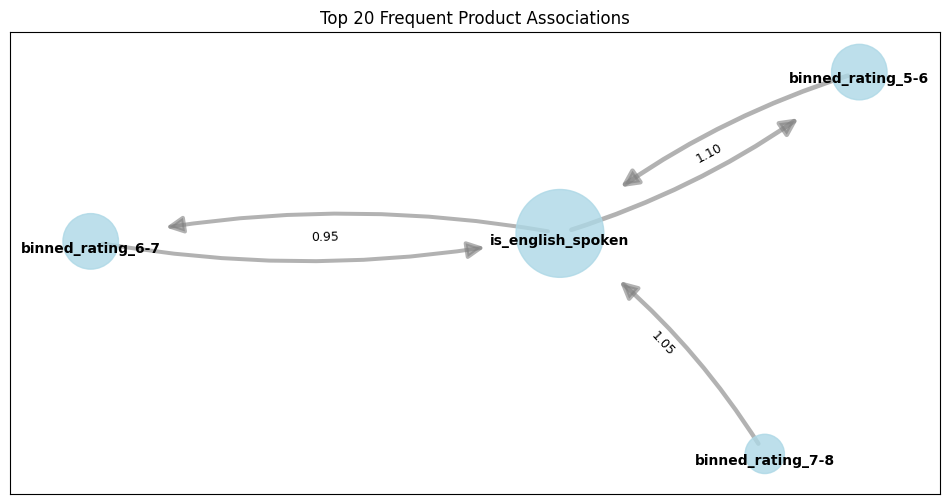

In [76]:
plot_association_graph(rules4, min_confidence=0.2, min_lift=0.9)

### 🤔 Is English Language Connected to Rating?

We examined whether English-speaking movies tend to perform better or worse in terms of audience ratings.

### 🔎 Key Observations:

1. **Rating 5–6 → English Spoken**  
   - Confidence: 91%  
   - Lift: 1.10  
   ✅ Movies rated in the 5–6 range are **very likely** to be in English. However, this reflects how dominant English is overall in the dataset.

2. **English Spoken → Rating 6–7**  
   - Confidence: 59.9%  
   - Lift: 0.95  
   ⚠️ Despite 6–7 being the most common rating bin, English-speaking movies are **slightly less likely** than random to fall into it.

3. **Rating 7–8 → English Spoken**  
   - Confidence: 87%  
   - Lift: 1.05  
   ✅ English-speaking movies are **mildly more likely** to score well (7–8) compared to others.

### 🎯 Conclusion:

While most English-speaking movies fall within the mid-range of ratings (5–7), they show **no strong correlation with high ratings overall**.  
There's only a **slight positive association** with very good ratings (7–8), and a **slight negative association** with average ones (6–7).
___

In [77]:
def recommend_rating_language_features(watched_features, rules, top_n=2):

    recommendations = []
    seen_recommendations = set()

    for _, row in rules.iterrows():
        antecedents = set(row['antecedents'])
        consequents = set(row['consequents'])
        support = row['support']
        confidence = row['confidence']
        lift = row['lift']

        if antecedents.issubset(watched_features):
            new_recs = consequents - watched_features
            for rec in new_recs:
                if rec not in seen_recommendations:
                    seen_recommendations.add(rec)
                    recommendations.append((rec, support, confidence, lift))

    recommendations.sort(key=lambda x: (x[2], x[3]), reverse=True)
    best_recommendations = recommendations[:top_n]

    formatted_recommendations = []
    for rec in best_recommendations:
        item, support, confidence, lift = rec
        explanation = (
            f"If you want: {watched_features}, I recommend: {item}.\n"
            f"Support: {support:.2f}, Confidence: {confidence:.2f}, Lift: {lift:.2f}."
        )
        formatted_recommendations.append(explanation)

    return formatted_recommendations


In [78]:
# Example Usage:
watched_features = {"binned_rating_6-7"}
recommendations = recommend_rating_language_features(watched_features, rules4)

for rec in recommendations:
    print(rec)

If you want: {'binned_rating_6-7'}, I recommend: is_english_spoken.
Support: 0.49, Confidence: 0.79, Lift: 0.95.


In [79]:
def recommend_movies_from_rating_language_rules(watched_features, rules, df, top_n_features=3, top_n_movies=5, min_confidence=0.5, min_lift=1.0):

    filtered_rules = rules[(rules['confidence'] >= min_confidence) & (rules['lift'] >= min_lift)]

    feature_recs = []
    seen_features = set()

    for _, row in filtered_rules.iterrows():
        antecedents = set(row['antecedents'])
        consequents = set(row['consequents'])
        support = row['support']
        confidence = row['confidence']
        lift = row['lift']

        if antecedents.issubset(watched_features):
            new_features = consequents - watched_features
            for feature in new_features:
                if feature not in seen_features:
                    seen_features.add(feature)
                    feature_recs.append((feature, support, confidence, lift))

    feature_recs.sort(key=lambda x: (x[2], x[3]), reverse=True)
    best_features = [rec[0] for rec in feature_recs[:top_n_features]]

    if not best_features:
        return "No new features to recommend based on current rules and thresholds."

    # Now filter movies that match any of these features
    movie_candidates = df.copy()

    feature_conditions = []
    for feature in best_features:
        if feature.startswith('binned_rating_'):
            rating_range = feature.replace('binned_rating_', '').split('-')
            lower = float(rating_range[0])
            upper = float(rating_range[1])
            condition = (df['vote_average'] >= lower) & (df['vote_average'] < upper)
            feature_conditions.append(condition)
        elif feature == 'is_english_spoken':
            condition = df['is_english_spoken'] == 1
            feature_conditions.append(condition)
        else:
            continue  # unknown feature type

    if not feature_conditions:
        return "No matching movies found for recommended features."

    combined_condition = feature_conditions[0]
    for condition in feature_conditions[1:]:
        combined_condition |= condition

    movie_candidates = movie_candidates[combined_condition]

    if 'weighted_rating' in movie_candidates.columns:
        movie_candidates = movie_candidates.sort_values(by='weighted_rating', ascending=False)

    columns_to_return = ['title']
    if 'weighted_rating' in movie_candidates.columns:
        columns_to_return.append('weighted_rating')

    return movie_candidates[columns_to_return].head(top_n_movies)


In [80]:
# Example Usage:
watched_features = {"is_english_spoken"}
movie_recs = recommend_movies_from_rating_language_rules(watched_features, rules4, df, top_n_features=3, top_n_movies=5, min_confidence=0.2, min_lift=0.95)
print(movie_recs)

                    title  weighted_rating
5616             Megamind         6.989771
553                  Cars         6.989482
577   Mission: Impossible         6.988948
8498              Shazam!         6.987367
8812  10 Cloverfield Lane         6.985094


______
## 🎬 Association Rule-Based Movie Recommendation System

We previously explored movie recommendations using separate feature sets:  
genres, binned ratings, runtimes, release years, spoken language, and production companies.

Now, we transition to a **comprehensive system** that combines all relevant binary and categorical features —  
including genres, audience type (`is_kid_friendly` / `is_adult_only`), release decade, ratings, studio info, and more.

By running the Apriori algorithm on the full dataset, we aim to:  
- Capture deeper patterns across feature combinations  
- Provide more relevant and diverse recommendations  
- Support explanations for why each movie is recommended

This unified approach improves both the **precision and interpretability** of the recommendations.


In [81]:
# Before building the system, we review the available features to decide which are relevant:  
df.columns

Index(['id', 'title', 'runtime', 'release_date', 'budget', 'revenue',
       'popularity', 'vote_average', 'vote_count', 'belongs_to_collection',
       'has_tagline', 'has_homepage', 'num_same_title', 'changed_title',
       'num_genres', 'Crime', 'History', 'Fantasy', 'Documentary', 'Mystery',
       'Action', 'Family', 'Comedy', 'Music', 'Horror', 'TV Movie', 'Western',
       'Science Fiction', 'Adventure', 'Animation', 'Thriller', 'War',
       'Romance', 'Drama', 'top10_prod_comps', 'num_production_companies',
       'main_production_country', 'num_production_countries',
       'num_spoken_languages', 'is_english_spoken', 'popularity_percentile',
       'weighted_rating', 'release_year', 'season',
       'return_on_investment_ratio', 'profit_or_loss', 'binned_rating',
       'binned_runtime', 'binned_release_year'],
      dtype='object')

In [82]:
df5 = df.copy()

In [83]:
genres = ['Music', 'Adventure', 'Thriller', 'Fantasy', 'Crime', 'Action', 'Romance', 'Animation',
          'Comedy', 'Documentary', 'History', 'TV Movie', 'War', 'Family', 'Horror',
          'Science Fiction', 'Mystery', 'Drama', 'Western']

In [84]:
df5.loc[df5['title'] == 'Begin Again', genres]

,Music,Adventure,Thriller,Fantasy,Crime,Action,Romance,Animation,Comedy,Documentary,History,TV Movie,War,Family,Horror,Science Fiction,Mystery,Drama,Western
7901,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False


In [85]:
# Create binary features for kid-friendly and adult-only movies based on genres
kid_unfriendly_genres = ['Horror', 'Crime', 'Thriller', 'War', 'History', 'Romance', 'Drama', 'Action', 'Science Fiction', 'Mystery']

df5['is_kid_friendly'] = ~df5[kid_unfriendly_genres].any(axis=1)

# override movies that are explicitly marked as family-friendly (example: in case of 'Mystery' + 'Family')
df5.loc[df5['Family'] == 1, 'is_kid_friendly'] = True

df5['is_adult_only'] = ~df5['is_kid_friendly']


In [86]:
df5[df5['title'] == 'Inception']['is_kid_friendly']

5005    False
Name: is_kid_friendly, dtype: bool

In [87]:
df5[df5['title'] == 'Harry Potter and the Prisoner of Azkaban']['is_kid_friendly']


406    True
Name: is_kid_friendly, dtype: bool

In [88]:
# Selected binary features for rule mining.

binary_features = [
    'belongs_to_collection',
    'is_kid_friendly',
    'is_adult_only',
    'is_english_spoken',
    'top10_prod_comps',
    'has_tagline',
    'has_homepage',
    'changed_title',
]


In [89]:
# Define the bins and labels (changed from previous test)
bins = [0, 1980, 2000, 2018, np.inf]
labels = ['Before 1980', '1980–1999', '2000–2017', '2018–2025']

df5['binned_release_year'] = pd.cut(df5['release_year'], bins=bins, labels=labels, include_lowest=True)
df5['binned_release_year'].value_counts()

binned_release_year
2000–2017      5759
1980–1999      2676
Before 1980    1310
2018–2025       208
Name: count, dtype: int64

In [90]:
# Define the bins and labels (changed from previous test)
bins = [0, 6, 7, 10]
labels = ['Low', 'Medium', 'High']

df5['binned_rating'] = pd.cut(df['weighted_rating'], bins=bins, labels=labels, include_lowest=False)

df5['binned_rating'].value_counts()

binned_rating
Medium    6244
Low       1975
High      1734
Name: count, dtype: int64

In [91]:
df5_binary = df5[genres + binary_features].copy()

In [92]:
df5_binary = pd.concat([
    df5_binary,
    pd.get_dummies(
        df5[['binned_rating', 'binned_release_year', 'binned_runtime']],
        prefix=['rating', 'release_year', 'runtime']
    )
], axis=1)

# Convert all features to boolean
df5_binary = df5_binary.astype(bool)

# Add movie titles for reference
df5_binary['title'] = df5['title'].values


In [109]:
df5_binary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 39 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Music                             9953 non-null   bool  
 1   Adventure                         9953 non-null   bool  
 2   Thriller                          9953 non-null   bool  
 3   Fantasy                           9953 non-null   bool  
 4   Crime                             9953 non-null   bool  
 5   Action                            9953 non-null   bool  
 6   Romance                           9953 non-null   bool  
 7   Animation                         9953 non-null   bool  
 8   Comedy                            9953 non-null   bool  
 9   Documentary                       9953 non-null   bool  
 10  History                           9953 non-null   bool  
 11  TV Movie                          9953 non-null   bool  
 12  War                 

In [94]:
df5_binary.head().T

,0,1,2,3,4
Music,False,False,False,False,False
Adventure,False,False,True,False,False
Thriller,False,True,False,False,False
Fantasy,False,False,False,False,False
Crime,True,True,False,False,False
Action,False,True,True,False,False
Romance,False,False,False,False,True
Animation,False,False,False,True,False
Comedy,True,False,False,False,True
Documentary,False,False,False,False,False


In [95]:
# Run Apriori on the combined binary-encoded dataset to discover frequent feature combinations
frequent_itemsets_all = apriori(df5_binary.drop(columns=['title']), min_support=0.05, use_colnames=True)

print("Frequent Itemsets Discovered for Combined Features:")
print(frequent_itemsets_all.sort_values(by='support', ascending=False).head(20))


Frequent Itemsets Discovered for Combined Features:
      support                                           itemsets
19   0.835929                                      (has_tagline)
17   0.825379                                (is_english_spoken)
16   0.810007                                    (is_adult_only)
190  0.763689                   (is_english_spoken, has_tagline)
177  0.683111                       (has_tagline, is_adult_only)
175  0.672461                 (is_english_spoken, is_adult_only)
23   0.627349                                    (rating_Medium)
611  0.623330    (is_english_spoken, has_tagline, is_adult_only)
29   0.590777                        (runtime_Long(90-120 Mins))
27   0.578620                           (release_year_2000–2017)
199  0.516729     (is_english_spoken, runtime_Long(90-120 Mins))
220  0.514217           (has_tagline, runtime_Long(90-120 Mins))
181  0.511805                     (rating_Medium, is_adult_only)
214  0.498443                       (r

In [96]:
# Generate association rules from all frequent itemsets using confidence threshold
rules5 = association_rules(frequent_itemsets_all, metric='confidence', min_threshold=0.2)

print("Association Rules Discovered for Combined Features:")

rules5.sort_values(by='lift', ascending=False)[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

Association Rules Discovered for Combined Features:


,antecedents,consequents,support,confidence,lift
373,"(is_kid_friendly, Adventure)",(Family),0.051643,0.826367,8.216610
376,(Family),"(is_kid_friendly, Adventure)",0.051643,0.513487,8.216610
10197,"(Comedy, is_english_spoken, Family)","(is_kid_friendly, has_tagline)",0.050638,0.952741,6.234472
10210,"(is_kid_friendly, has_tagline)","(Comedy, is_english_spoken, Family)",0.050638,0.331361,6.234472
5377,"(is_kid_friendly, has_tagline)","(is_english_spoken, Family)",0.079775,0.522025,6.163363
5380,"(is_english_spoken, Family)","(is_kid_friendly, has_tagline)",0.079775,0.941874,6.163363
10201,"(Comedy, Family, has_tagline)","(is_english_spoken, is_kid_friendly)",0.050638,0.940299,6.149009
10206,"(is_english_spoken, is_kid_friendly)","(Comedy, Family, has_tagline)",0.050638,0.331143,6.149009
5379,"(Family, has_tagline)","(is_kid_friendly, is_english_spoken)",0.079775,0.929742,6.079978
5378,"(is_kid_friendly, is_english_spoken)","(Family, has_tagline)",0.079775,0.521682,6.079978


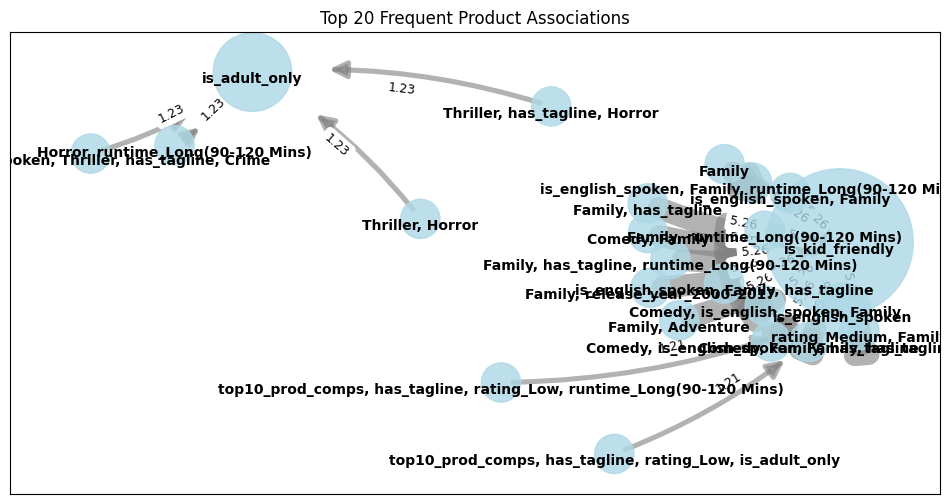

In [97]:
plot_association_graph(rules5, min_confidence=0.7, min_lift=1.1, max_rules=20)

In [98]:
# Filter rules to keep only strong associations with high confidence and meaningful lift

rules5 = rules5[
    (rules5['confidence'] >= 0.7) &
    (rules5['lift'] >= 1.1)
]

### 🎬 Recommendation Function

- ✅ **Partial Rule Matching**:  
  Allows rules to match even if only ~70% of features overlap, increasing flexibility and recall.

- 📊 **Feature Scoring by Lift**:  
  Recommended features are ranked by average lift and how many of them match each candidate movie.

- ⭐ **Personalized Movie Ranking**:  
  Final movie scores include lift-based score + rating bonus for highly rated movies.

- 🔒 **Audience Filtering**:  
  If the watched movie is labeled `is_kid_friendly` or `is_adult_only`, recommendations are filtered accordingly.

- 📈 **Sorted by Rating**:  
  Results are sorted by `weighted_rating` to prioritize high-quality suggestions.


In [99]:
def recommend_movies_from_feature_rules(watched_features, rules, df, top_n_features=3, top_n_movies=5):
    feature_recs = []
    seen_features = set()

    # Compute how strongly a rule's antecedents match the watched features
    def rule_match_strength(antecedents):
        return len(antecedents & watched_features) / len(antecedents)

    # Determine audience group based on watched movie's features
    is_kid = 'is_kid_friendly' in watched_features
    is_adult = 'is_adult_only' in watched_features

    # Collect new features from matching rules
    for _, row in rules.iterrows():
        antecedents = set(row['antecedents'])
        consequents = set(row['consequents'])

        if rule_match_strength(antecedents) >= 0.70:
            new_features = consequents - watched_features
            for feature in new_features:
                if feature not in seen_features and feature in df.columns:
                    seen_features.add(feature)
                    feature_recs.append((feature, row['support'], row['confidence'], row['lift']))

    # Sort new features by confidence and lift
    feature_recs.sort(key=lambda x: (x[2], x[3]), reverse=True)
    best_features = [rec[0] for rec in feature_recs[:top_n_features]]

    if not best_features:
        return "No new features to recommend based on current rules."

    # Filter movies that contain at least one of the best new features
    feature_conditions = [(df[feature] == True) for feature in best_features if feature in df.columns]

    if not feature_conditions:
        return "No matching movies found for recommended features."

    # Combine feature conditions using OR
    combined_condition = feature_conditions[0]
    for condition in feature_conditions[1:]:
        combined_condition |= condition

    movie_candidates = df[combined_condition]

    # Apply audience filtering: only recommend kid or adult movies as appropriate
    if is_kid:
        movie_candidates = movie_candidates[movie_candidates['is_kid_friendly'] == True]
    elif is_adult:
        movie_candidates = movie_candidates[movie_candidates['is_adult_only'] == True]

    # Sort by weighted rating if available
    if 'weighted_rating' in movie_candidates.columns:
        movie_candidates = movie_candidates.sort_values(by='weighted_rating', ascending=False)

    # Return top N movies with titles (and rating if available)
    columns_to_return = ['title']
    if 'weighted_rating' in movie_candidates.columns:
        columns_to_return.append('weighted_rating')

    return movie_candidates[columns_to_return].head(top_n_movies)


In [100]:
# Extract active features of the selected movie
def get_watched_features(movie_title, df_binary):
    # Get the active features (value 1/True) for a given movie
    movie_row = df_binary[df_binary['title'] == movie_title]

    if movie_row.empty:
        return f"Movie '{movie_title}' not found in the dataset."

    watched_features = set(
        movie_row.drop(columns=['title'])
        .iloc[0]
        .loc[lambda x: x == 1]
        .index
    )
    
    return watched_features

In [101]:
movie_title = 'Frozen'

# Get active features for the selected movie
watched_features = get_watched_features(movie_title, df5_binary)

print(f"Selected Movie: {movie_title}")
print("Active Features:")
print(sorted(watched_features))

recommend_movies_from_feature_rules(watched_features, rules5, df5_binary)


Selected Movie: Frozen
Active Features:
['Adventure', 'Animation', 'Family', 'Fantasy', 'belongs_to_collection', 'has_homepage', 'has_tagline', 'is_english_spoken', 'is_kid_friendly', 'rating_High', 'release_year_2000–2017', 'runtime_Long(90-120 Mins)', 'top10_prod_comps']


,title
18,The Simpsons Movie
67,Charlie and the Chocolate Factory
109,The Wizard
156,Willy Wonka & the Chocolate Factory
160,Oliver Twist


In [102]:
movie_title = 'Inception'

# Get active features for the selected movie
watched_features = get_watched_features(movie_title, df5_binary)

print(f"Selected Movie: {movie_title}")
print("Active Features:")
print(sorted(watched_features))

recommend_movies_from_feature_rules(watched_features, rules5, df5_binary)


Selected Movie: Inception
Active Features:
['Action', 'Adventure', 'Science Fiction', 'has_homepage', 'has_tagline', 'is_adult_only', 'is_english_spoken', 'rating_High', 'release_year_2000–2017', 'runtime_Very Long(Over 120 Mins)', 'top10_prod_comps']


,title
0,Four Rooms
1,Judgment Night
4,Forrest Gump
5,American Beauty
6,Citizen Kane


## 🧠 Feature-Based Movie Recommendation System – Summary

### What We Did:
We built a flexible and smart recommendation function based on association rules mined from movie features.

### Key Steps:
- **Binary Encoding of Features**:  
  Converted movie metadata (genres, rating level, release period, production company, etc.) into boolean features using one-hot encoding.

- **Frequent Pattern Mining**:  
  Applied the Apriori algorithm to discover common feature combinations across movies (with `min_support=0.05`).

- **Association Rule Generation**:  
  Generated rules based on frequent feature sets using a confidence threshold (e.g. `min_confidence=0.2`) and sorted by `lift`.

- **Recommendation Function Enhancements**:
  - Supports **partial feature matching**: rules are selected if ≥70% of their antecedents match the current movie.
  - Filters recommendations based on **audience tags** (`is_kid_friendly` / `is_adult_only`) to ensure appropriate suggestions.
  - Ranks movies based on **lift-weighted feature matching** and optional **rating-based sorting** (`weighted_rating`).
  - Returns **top N movies** that best align with newly recommended features.

### Benefits:
- 📈 Improved coverage by allowing **partial rule matches**.
- 🎯 More relevant recommendations by using **audience-aware filtering**.
- ⭐ Prioritized results using **weighted scores and ratings**.

This approach balances rule quality, personalization, and relevance, leading to stronger and more intuitive movie recommendations.


___
## 🎥 Additional Use Cases for Association Rules in Movie Data (Beyond Recommendation Systems)

In addition to using association rules for recommending movies based on user history, the discovered patterns can support a range of other valuable applications in content platforms, enhancing user experience, content organization, and marketing strategies:

1. *Promoting Movie Bundles*  
   Movies from genres that frequently appear together in association rules can be bundled and marketed together.  
   For example, offer a viewing bundle that includes both a romantic movie and a comedy if those genres often co-occur in the data.

2. *Organizing the Movie Catalog Intelligently*  
   Similar to product placement in a physical store, movies can be positioned close to each other in the user interface based on associative patterns.  
   For example, when a user is viewing a paid movie, suggest additional movies next to it that are *similar to ones they previously enjoyed* (not necessarily from the same genre), based on discovered associations.  
   This creates a dynamic, personalized browsing experience.

3. *Content Curation (Playlists and Collections)*  
   Create thematic collections of movies using frequent genre combinations found through association rules.  
   For example:  
   - “Action-Comedy Hits”  
   - “Romantic Dramas”  
   - “Family Animation with Musical Elements”  
   These curated playlists help highlight relevant content and can increase user engagement by surfacing meaningful combinations.

---

## ✅ Summary

- Each rule set has its **own tailored recommendation functions**.
- We can now analyze how Apriori rules generate recommendations from multiple perspectives: genres, time period, runtime, ratings, languages, and collections.

---

## 🚀 Next Step: Cosine Similarity

Now that we’ve fully explored rule-based recommendations, we will build a **Cosine Similarity Recommender**, to compare collaborative-like recommendations vs. association-rule-based recommendations.


In [103]:
def build_content_matrix(df):

    # Features that are already binary
    feature_cols = [
        'belongs_to_collection',
        'is_english_spoken'
    ]

    # Genres
    genre_cols = [
        'Action', 'Comedy', 'Drama', 'Romance', 'Thriller', 'Science Fiction',
        'Fantasy', 'Horror', 'Animation', 'Adventure', 'Crime', 'Family',
        'Mystery', 'History', 'War', 'Music', 'Western', 'Documentary', 'TV Movie'
    ]

    # One-hot encode binned_release_year and binned_runtime using get_dummies
    binned_cols = df[['binned_release_year', 'binned_runtime', 'binned_rating']]
    binned_dummies = pd.get_dummies(binned_cols, prefix=['binned_release_year', 'binned_runtime', 'binned_rating'])

    # Combine everything
    final_matrix = pd.concat([
        df[feature_cols + genre_cols].reset_index(drop=True),
        binned_dummies.reset_index(drop=True)
    ], axis=1)

    return final_matrix

def recommend_movies(title, df, sim_matrix, top_n=5):

    indices = pd.Series(df.index, index=df['title']).drop_duplicates()

    if title not in indices:
        return f"Movie '{title}' not found in dataset."

    idx = indices[title]
    sim_scores = list(enumerate(sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n + 1]

    results = []
    for i, score in sim_scores:
        movie = df.iloc[i]
        results.append({
            'title': movie['title'],
            'similarity_score': round(score, 3),
            'weighted_rating': movie.get('weighted_rating', 'N/A'),
        })

    return pd.DataFrame(results)

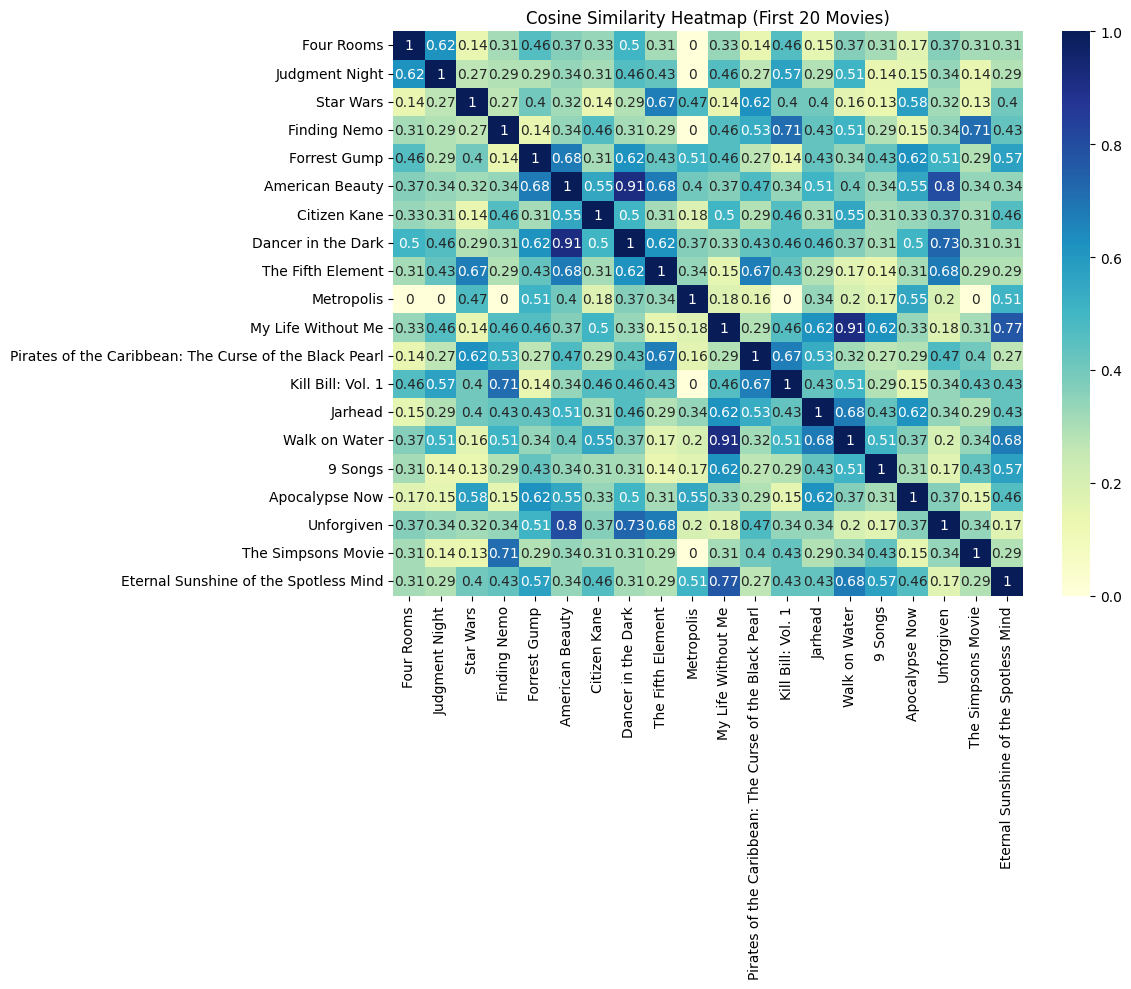

In [104]:
from sklearn.metrics.pairwise import cosine_similarity

content_matrix = build_content_matrix(df)
cosine_sim = cosine_similarity(content_matrix, content_matrix)

sample_size=20

labels = df['title'].head(sample_size)
matrix = cosine_sim[:sample_size, :sample_size]

plt.figure(figsize=(12, 10))
sns.heatmap(matrix, xticklabels=labels, yticklabels=labels, cmap="YlGnBu", annot=True)
plt.title(f"Cosine Similarity Heatmap (First {sample_size} Movies)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [105]:
recommendations = recommend_movies("Dancer in the Dark", df, cosine_sim, top_n=16)
print(recommendations)

                      title  similarity_score  weighted_rating
0                    Casino             1.000         7.969324
1              A Bronx Tale             1.000         7.815865
2       Murder in the First             1.000         7.072808
3           A Perfect World             1.000         7.415695
4               American Me             1.000         7.174857
5              Jackie Brown             0.926         7.342745
6                  Sleepers             0.926         7.567481
7   The Talented Mr. Ripley             0.926         7.171572
8                 Cape Fear             0.926         7.230957
9            A Time to Kill             0.926         7.335386
10                  Traffic             0.926         7.040553
11            Donnie Brasco             0.926         7.508591
12               Set It Off             0.926         7.014615
13            A Simple Plan             0.926         7.117153
14        Dolores Claiborne             0.926         7

# 🎯 Hybrid Movie Recommendation System: Rule-Based + Cosine Similarity

After building and testing two independent recommendation systems, we are now ready to combine them into a unified hybrid recommender for optimal performance.

---

## ✅ Phase 1: Rule-Based Recommendation System

We created multiple rule-based recommenders using Apriori Association Rule Mining.  
For each rule set, we implemented tailored functions that:
- Generate new feature recommendations.
- Recommend actual movies based on discovered rules.

---

## ✅ Phase 2: Content-Based Cosine Similarity Recommender

We engineered a content matrix combining our features used in the Apriori section.  

We then calculated cosine similarity across all movies to recommend titles similar to any given movie, even when no association rules directly apply.

---

## 🚀 Phase 3: Hybrid Recommendation System

Both systems have complementary strengths:
- **Apriori Rules** capture strong known patterns and associations discovered from the data.
- **Cosine Similarity** captures proximity between movies across multiple content dimensions, even when no strong rule exists.

We will now combine both approaches into one hybrid model:
- Use rules when applicable and strong.
- Use similarity for fine-grained personalization.
- Combine both signals to produce balanced, explainable recommendations.

---

🧠 This hybrid system allows us to:
- Improve recommendation diversity.
- Handle cold-start users better.
- Leverage both pattern mining and content-based similarity.

🔥 The result: a much more robust and powerful recommendation engine.



In [106]:
# Combine all rules together:
all_rules = pd.concat([rules1, rules2, rules3, rules4, rules5]).reset_index(drop=True)

# Drop duplicates based on antecedents and consequents
all_rules = all_rules.drop_duplicates(subset=['antecedents', 'consequents'])

In [107]:
def hybrid_recommender(title, df, rules, cosine_sim, top_n=10, rule_weight=0.6, sim_weight=0.4, min_confidence=0.4, min_lift=0.95):
    
    # Build index
    indices = pd.Series(df.index, index=df['title']).drop_duplicates()
    if title not in indices:
        return f"Movie '{title}' not found in dataset."
    
    idx = indices[title]
    
    # Extract feature values for this movie
    movie_row = df.iloc[idx]
    
    # Build watched_features for rules
    watched_features = set()
    
    # Collect binned rating
    watched_features.add(f"binned_rating_{movie_row['binned_rating']}")

    # Collect binary columns
    for col in ['belongs_to_collection', 'is_english_spoken']:
        if movie_row[col] == 1:
            watched_features.add(col)
    
    # Collect binned_release_year
    watched_features.add('binned_release_year_' + str(movie_row['binned_release_year']))
    
    # Collect binned_runtime
    watched_features.add('binned_runtime_' + str(movie_row['binned_runtime']))
    
    # Collect genres
    genre_cols = [
        'Action', 'Comedy', 'Drama', 'Romance', 'Thriller', 'Science Fiction',
        'Fantasy', 'Horror', 'Animation', 'Adventure', 'Crime', 'Family',
        'Mystery', 'History', 'War', 'Music', 'Western', 'Documentary', 'TV Movie'
    ]
    for genre in genre_cols:
        if genre in df.columns and movie_row[genre] == 1:
            watched_features.add(genre)
    
    # Filter rules
    filtered_rules = rules[(rules['confidence'] >= min_confidence) & (rules['lift'] >= min_lift)]

    # Rule score accumulation
    movie_rule_scores = {}

    for _, row in filtered_rules.iterrows():
        antecedents = set(row['antecedents'])
        consequents = set(row['consequents'])
        confidence = row['confidence']
        lift = row['lift']

        if antecedents.issubset(watched_features):
            rule_score = confidence * lift

            for feature in consequents - watched_features:
                condition = None

                if feature.startswith('binned_rating_'):
                    rating_range = feature.replace('binned_rating_', '').split('-')
                    lower = float(rating_range[0])
                    upper = float(rating_range[1])
                    condition = (df['vote_average'] >= lower) & (df['vote_average'] < upper)

                elif feature.startswith('binned_release_year_'):
                    decade = feature.replace('binned_release_year_', '')
                    condition = df['binned_release_year'] == decade

                elif feature.startswith('binned_runtime_'):
                    runtime = feature.replace('binned_runtime_', '')
                    condition = df['binned_runtime'] == runtime

                elif feature == 'belongs_to_collection':
                    condition = df['belongs_to_collection'] == 1

                elif feature == 'is_english_spoken':
                    condition = df['is_english_spoken'] == 1

                elif feature in df.columns:
                    condition = df[feature] == 1

                if condition is not None:
                    matching_movies = df[condition]
                    for movie_id in matching_movies.index:
                        movie_title = df.loc[movie_id, 'title']
                        movie_rule_scores[movie_title] = movie_rule_scores.get(movie_title, 0) + rule_score

    # Build rule dataframe
    rule_movies = pd.DataFrame.from_dict(movie_rule_scores, orient='index', columns=['rule_score_raw']).reset_index()
    rule_movies.rename(columns={'index': 'title'}, inplace=True)

    # Normalize rule scores
    if not rule_movies.empty:
        max_rule_score = rule_movies['rule_score_raw'].max()
        rule_movies['rule_score_norm'] = rule_movies['rule_score_raw'] / max_rule_score
    else:
        rule_movies['rule_score_norm'] = 0

    rule_movies['rule_score_weighted'] = rule_movies['rule_score_norm'] * rule_weight

    # Cosine similarity recommendations
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+20]

    sim_movies = []
    for i, score in sim_scores:
        movie = df.iloc[i]
        sim_movies.append({
            'title': movie['title'],
            'sim_score_raw': score,
            'sim_score_weighted': score * sim_weight
        })

    sim_movies_df = pd.DataFrame(sim_movies)

    # Merge rule-based and similarity-based recommendations
    if not rule_movies.empty:
        merged = pd.merge(rule_movies, sim_movies_df, on='title', how='outer')
        merged['rule_score_weighted'] = merged['rule_score_weighted'].fillna(0)
        merged['rule_score_norm'] = merged['rule_score_norm'].fillna(0)
        merged['rule_score_raw'] = merged['rule_score_raw'].fillna(0)
        merged['sim_score_weighted'] = merged['sim_score_weighted'].fillna(0)
        merged['sim_score_raw'] = merged['sim_score_raw'].fillna(0)
    else:
        merged = sim_movies_df.copy()
        merged['rule_score_weighted'] = 0
        merged['rule_score_norm'] = 0
        merged['rule_score_raw'] = 0

    # Compute final score
    merged['final_score'] = merged['rule_score_weighted'] + merged['sim_score_weighted']
    merged = merged[merged['title'] != title]
    merged = merged.sort_values(by='final_score', ascending=False)

    return merged[['title', 'rule_score_raw', 'rule_score_norm', 'rule_score_weighted', 'sim_score_raw', 'sim_score_weighted', 'final_score']].head(top_n)


In [108]:
hybrid_recommendations = hybrid_recommender(
    "Dancer in the Dark", df, all_rules, cosine_sim, top_n=15, rule_weight=0.3, sim_weight=0.7, min_confidence=0.5, min_lift=1.0
)

hybrid_recommendations

,title,rule_score_raw,rule_score_norm,rule_score_weighted,sim_score_raw,sim_score_weighted,final_score
1602,Hamlet,39.716546,0.969073,0.290722,0.912871,0.639010,0.929732
1797,Cape Fear,26.688947,0.651203,0.195361,0.925820,0.648074,0.843435
6961,American Me,13.027599,0.317870,0.095361,1.000000,0.700000,0.795361
5889,Casino,13.027599,0.317870,0.095361,1.000000,0.700000,0.795361
6409,Murder in the First,13.027599,0.317870,0.095361,1.000000,0.700000,0.795361
6075,A Bronx Tale,13.027599,0.317870,0.095361,1.000000,0.700000,0.795361
6514,A Perfect World,13.027599,0.317870,0.095361,1.000000,0.700000,0.795361
6483,Set It Off,13.027599,0.317870,0.095361,0.925820,0.648074,0.743435
6619,A Simple Plan,13.027599,0.317870,0.095361,0.925820,0.648074,0.743435
6039,The Talented Mr. Ripley,13.027599,0.317870,0.095361,0.925820,0.648074,0.743435


## ✅ Fully Weighted Hybrid Recommendation System

In the final phase, we developed a fully weighted hybrid recommendation engine that combines both rule-based and content-based approaches into a unified model:

- 🔎 **Unified Rule Engine:**  
  We merged all 4 rule sets (genres, release year & runtime, collection & rating, rating & language) into a single rule system.

- 🎯 **Weighted Rule Scoring:**  
  Each rule contributes to recommendations based on its strength:
  - For every rule that fires (antecedent fully satisfied), we calculate:
    ```
    rule_score = confidence × lift
    ```
  - When multiple rules recommend the same movie, their scores are accumulated:
    ```
    rule_score_raw = Σ (confidence × lift)
    ```
  - The accumulated raw rule scores are globally normalized across all recommended movies:
    ```
    rule_score_norm = rule_score_raw / max(rule_score_raw)
    ```
  - Finally, the normalized rule score is weighted:
    ```
    rule_score_weighted = rule_score_norm × rule_weight
    ```

- 🔬 **Cosine Similarity Component:**  
  In parallel, we computed cosine similarity using a content matrix built from genres, binned ratings, release years, runtimes, collections, and languages.

- ⚖ **Hybrid Scoring Mechanism:**  
  The final recommendation score is a weighted combination of:
  - The normalized rule-based score.
  - The cosine similarity score.
  - Customizable weights allow tuning the contribution of each system:
    ```
    final_score = rule_score_weighted + sim_score_weighted
    ```

- 📊 **Transparent Output:**  
  The final recommender provides:
  - Raw rule score (`rule_score_raw`)
  - Normalized rule score (`rule_score_norm`)
  - Weighted rule score (`rule_score_weighted`)
  - Raw similarity score (`sim_score_raw`)
  - Weighted similarity score (`sim_score_weighted`)
  - Final combined score (`final_score`)

The hybrid system balances strong association patterns with fine-grained content similarity, resulting in more diverse, explainable, and effective recommendations.
